# Transition Validation
Thin notebook that reuses `validation_plots.shared_validation` plotting functions.

In [1]:
from pathlib import Path
import os
import subprocess
import tkinter as tk
from tkinter import filedialog
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from imu_features.config import PipelineConfig
import validation_plots.shared_validation as sv


In [2]:
DATA_ROOT = Path("Data")
PATIENT_ID = "patient_08"
DATE = None             # e.g. "2026-03-08" or None => latest
USE_TKINTER_CHOOSER = True      # set True to open folder chooser UI

PLOT_PARAMS = {
    "window_gate": {
        "window_sec": 1,
        "transition_min_amp_threshold": 0.10,   # fallback only
        "transition_threshold_k": 3.0,
        "transition_min_duration_s": 0.5,
    },
}

COLUMN_MAPPING_OVERRIDE = {
    "timestamp": ["Timestamp", "timestamp", "time", "Time"],
    "accel_x": ["Accel_X", "accel_x", "acc_x"],
    "accel_y": ["Accel_Y", "accel_y", "acc_y"],
    "accel_z": ["Accel_Z", "accel_z", "acc_z"],
    "useracc_x": ["UserAccel_X", "useracc_x", "linacc_x", "linearacc_x"],
    "useracc_y": ["UserAccel_Y", "useracc_y", "linacc_y", "linearacc_y"],
    "useracc_z": ["UserAccel_Z", "useracc_z", "linacc_z", "linearacc_z"],
    "gyro_x": ["Gyro_X", "gyro_x", "gyr_x"],
    "gyro_y": ["Gyro_Y", "gyro_y", "gyr_y"],
    "gyro_z": ["Gyro_Z", "gyro_z", "gyr_z"],
}

PIPELINE_CONFIG = PipelineConfig()
PIPELINE_CONFIG.column_candidates = COLUMN_MAPPING_OVERRIDE
print("Transition config ready")


Transition config ready


In [3]:
CHOSEN_DIR = None
LAST_TKINTER_DIR_PATH = Path(".data_last_tkinter_dir.txt")

def _last_tkinter_dir(default_dir=None):
    default_path = Path(default_dir or DATA_ROOT)
    try:
        if LAST_TKINTER_DIR_PATH.exists():
            cached = Path(LAST_TKINTER_DIR_PATH.read_text().strip()).expanduser()
            if cached.exists():
                return cached
    except Exception:
        pass
    return default_path

def _remember_tkinter_dir(selected_dir):
    try:
        if selected_dir is not None:
            LAST_TKINTER_DIR_PATH.write_text(str(Path(selected_dir).resolve()))
    except Exception:
        pass

def _activate_notebook_process_for_dialog():
    if os.name != "posix":
        return
    try:
        subprocess.run(
            [
                "osascript",
                "-e",
                (
                    'tell application "System Events" '
                    f'to set frontmost of first process whose unix id is {os.getpid()} to true'
                ),
            ],
            check=False,
            capture_output=True,
            text=True,
        )
    except Exception:
        pass

def choose_directory_tkinter(initial_dir=None):
    try:
        start_dir = _last_tkinter_dir(initial_dir)
        _activate_notebook_process_for_dialog()
        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        root.lift()
        root.focus_force()
        root.update()
        root.update_idletasks()
        try:
            root.eval('tk::PlaceWindow . center')
        except Exception:
            pass
        _activate_notebook_process_for_dialog()
        selected = filedialog.askdirectory(
            parent=root,
            initialdir=str(Path(start_dir).resolve()),
            title="Choose activity date folder",
            mustexist=True,
        )
        root.attributes("-topmost", False)
        root.destroy()
        chosen = Path(selected) if selected else None
        _remember_tkinter_dir(chosen)
        return chosen
    except Exception as exc:
        print(f"tkinter chooser unavailable ({exc}); using configured path.")
        return None

CHOSEN_DIR = choose_directory_tkinter(initial_dir=DATA_ROOT) if USE_TKINTER_CHOOSER else None
print("Chosen directory:", CHOSEN_DIR)


Chosen directory: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Scrapper/patient_103/2026-03-08/activity_1


In [4]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)

resolve_date_dir = sv.resolve_date_dir
discover_activity_files = sv.discover_activity_files
load_activity_file = sv.load_activity_file
plot_walk_validation = sv.plot_walk_validation
plot_turn_validation = sv.plot_turn_validation
plot_transition_validation = sv.plot_transition_validation
plot_turn_symmetry_comparison = sv.plot_turn_symmetry_comparison
plot_turn_pair_xcorr = sv.plot_turn_pair_xcorr
plot_transition_pair_xcorr = sv.plot_transition_pair_xcorr

print("shared_validation helpers imported")


shared_validation helpers imported


## Base Directory

In [5]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)

if CHOSEN_DIR is not None:
    BASE_DIR = Path(CHOSEN_DIR)
else:
    BASE_DIR = resolve_date_dir(DATA_ROOT, PATIENT_ID, DATE)
    if DATE is None:
        DATE = BASE_DIR.name

print("Base directory:", BASE_DIR)


Base directory: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Scrapper/patient_103/2026-03-08/activity_1


In [6]:
def plot_loaded_sensor(df_loaded, sensor_name, x_col, y_col, z_col, show_x=True, show_y=True, show_z=True, show_resultant=True, source_label=None):
    if df_loaded is None:
        print(f"[SKIP] {sensor_name}: no loaded activity dataframe")
        return
    if 'time_s' not in df_loaded.columns:
        print(f"[SKIP] {sensor_name}: loaded dataframe missing time_s")
        return
    needed = [x_col, y_col, z_col]
    missing = [c for c in needed if c not in df_loaded.columns]
    if missing:
        print(f"[SKIP] {sensor_name}: missing columns {missing}")
        return

    t_plot = pd.to_numeric(df_loaded['time_s'], errors='coerce').to_numpy(dtype=float)
    x = pd.to_numeric(df_loaded[x_col], errors='coerce').to_numpy(dtype=float)
    y = pd.to_numeric(df_loaded[y_col], errors='coerce').to_numpy(dtype=float)
    z = pd.to_numeric(df_loaded[z_col], errors='coerce').to_numpy(dtype=float)
    resultant = np.sqrt(x**2 + y**2 + z**2)

    plt.figure(figsize=(10, 4))
    if show_x:
        plt.plot(t_plot, x, label='x', linewidth=1.0)
    if show_y:
        plt.plot(t_plot, y, label='y', linewidth=1.0)
    if show_z:
        plt.plot(t_plot, z, label='z', linewidth=1.0)
    if show_resultant:
        plt.plot(t_plot, resultant, label='resultant', linewidth=1.8, color='black')
    title_suffix = f" ({source_label})" if source_label else ''
    plt.title(f"{sensor_name}{title_suffix}")
    plt.xlabel('Time (s)')
    plt.ylabel('Value')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right', fontsize=7, framealpha=0.80, borderpad=0.25, labelspacing=0.25, handlelength=1.6)
    plt.show()


## Load Sit To Stand File

In [7]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
activity_files = discover_activity_files(BASE_DIR, ["sit_to_stand", "stand_to_sit"])
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")
SIT_TO_STAND_PATH = activity_files.get("sit_to_stand")
SIT_TO_STAND_DF = None
SIT_TO_STAND_META = None
SIT_TO_STAND_SUMMARY = None
SIT_TO_STAND_CACHE = None
SIT_TO_STAND_FLEX_EXT = None
if SIT_TO_STAND_PATH is not None:
    print(f"\n[PROCESS] sit_to_stand: {SIT_TO_STAND_PATH}")
    SIT_TO_STAND_DF, SIT_TO_STAND_META = load_activity_file(SIT_TO_STAND_PATH)
    print("Loaded plot file:", SIT_TO_STAND_PATH)
else:
    print("[SKIP] sit_to_stand: not available")


Discovered activity files:
  sit_to_stand: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Scrapper/patient_103/2026-03-08/activity_1/sit_to_stand/synchronized/exercise_data_4797_Muhammad.Ahmed01_synchronized.csv
  stand_to_sit: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Scrapper/patient_103/2026-03-08/activity_1/stand_to_sit/synchronized/exercise_data_4798_Muhammad.Ahmed01_synchronized.csv

[PROCESS] sit_to_stand: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Scrapper/patient_103/2026-03-08/activity_1/sit_to_stand/synchronized/exercise_data_4797_Muhammad.Ahmed01_synchronized.csv
Loaded plot file: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Scrapper/patient_103/2026-03-08/activity_1/sit_to_stand/synchronized/exercise_data_4797_Muhammad.Ahmed01_synchronized.csv


## Sit To Stand Accelerometer

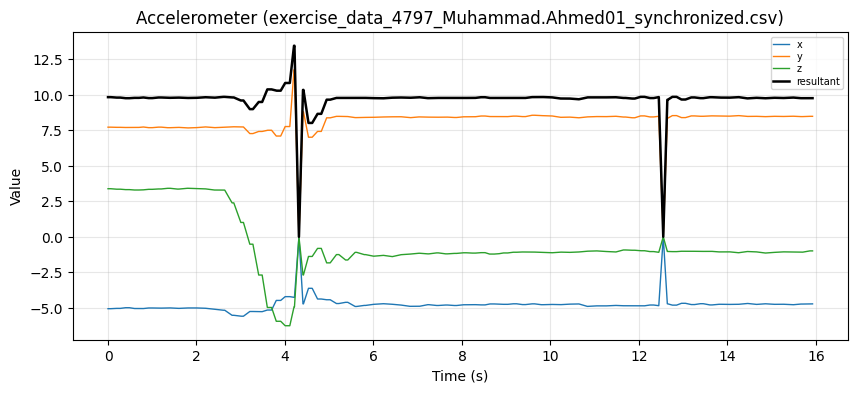

In [8]:
SHOW_ACCEL_X = True
SHOW_ACCEL_Y = True
SHOW_ACCEL_Z = True
SHOW_ACCEL_RESULTANT = True
plot_loaded_sensor(SIT_TO_STAND_DF, "Accelerometer", "accel_x", "accel_y", "accel_z", SHOW_ACCEL_X, SHOW_ACCEL_Y, SHOW_ACCEL_Z, SHOW_ACCEL_RESULTANT, source_label=SIT_TO_STAND_PATH.name if SIT_TO_STAND_PATH else None)


## Sit To Stand Gyroscope

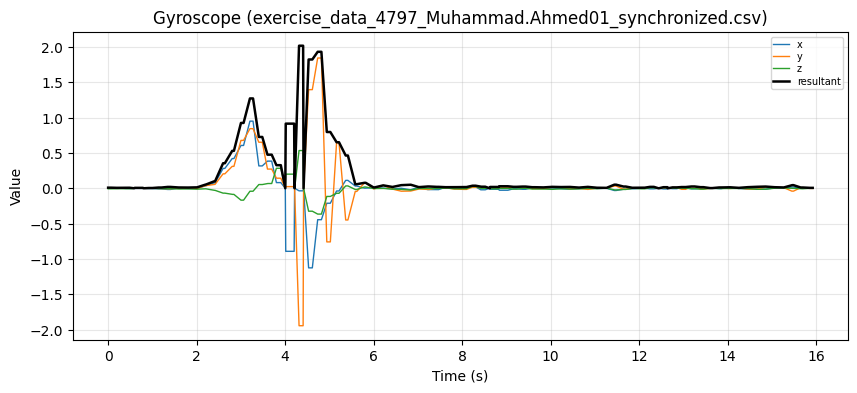

In [9]:
SHOW_GYRO_X = True
SHOW_GYRO_Y = True
SHOW_GYRO_Z = True
SHOW_GYRO_RESULTANT = True
plot_loaded_sensor(SIT_TO_STAND_DF, "Gyroscope", "gyro_x", "gyro_y", "gyro_z", SHOW_GYRO_X, SHOW_GYRO_Y, SHOW_GYRO_Z, SHOW_GYRO_RESULTANT, source_label=SIT_TO_STAND_PATH.name if SIT_TO_STAND_PATH else None)


## Sit To Stand User Accelerometer

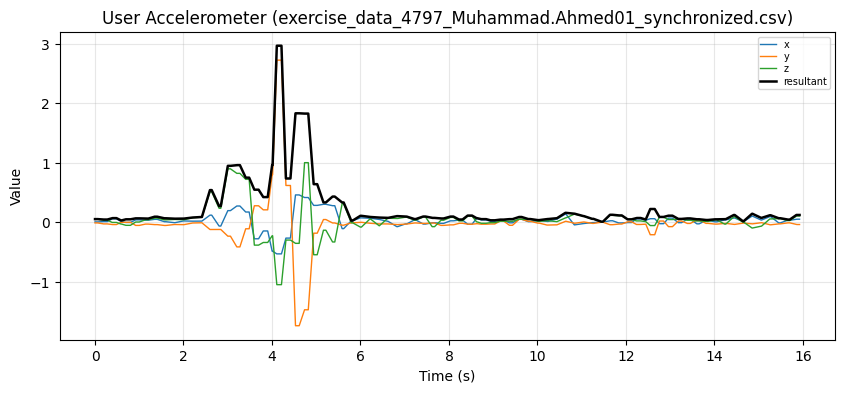

In [10]:
SHOW_USERACC_X = True
SHOW_USERACC_Y = True
SHOW_USERACC_Z = True
SHOW_USERACC_RESULTANT = True
plot_loaded_sensor(SIT_TO_STAND_DF, "User Accelerometer", "useracc_x", "useracc_y", "useracc_z", SHOW_USERACC_X, SHOW_USERACC_Y, SHOW_USERACC_Z, SHOW_USERACC_RESULTANT, source_label=SIT_TO_STAND_PATH.name if SIT_TO_STAND_PATH else None)


## Sit To Stand Feature Plots

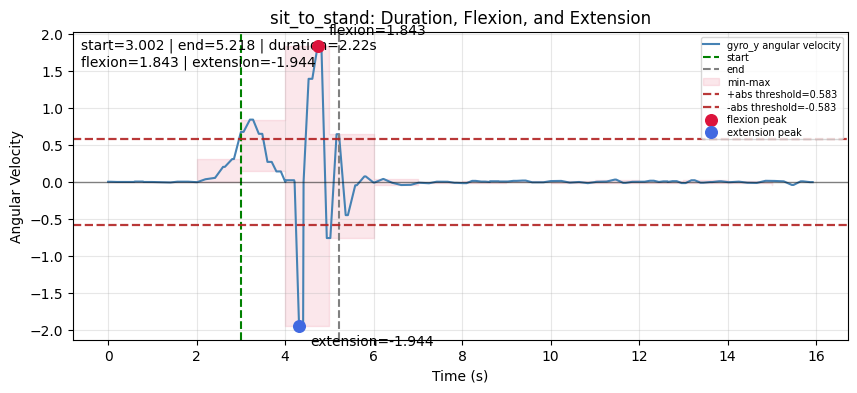

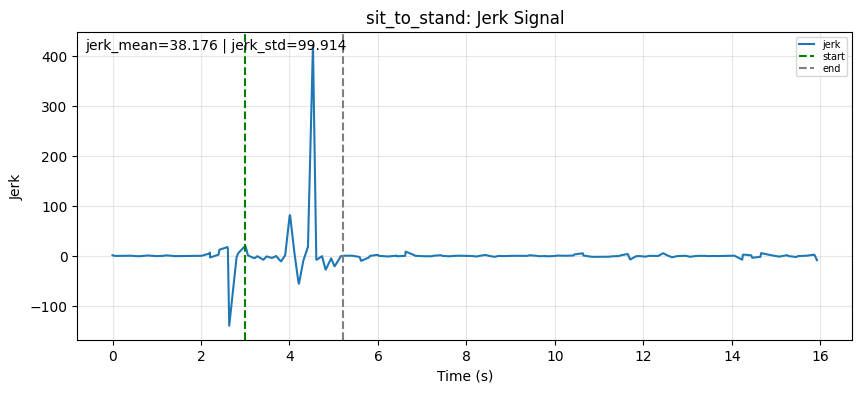

{'activity': 'sit_to_stand', 'start_time_s': 3.001999855041504, 'end_time_s': 5.2179999351501465, 'duration_s': 2.2160000801086426, 'flexion_peak': 1.842529058456421, 'extension_peak': -1.9440178871154783}


,activity,start_time_s,end_time_s,duration_s,flexion_peak,extension_peak
0,sit_to_stand,3.002,5.218,2.216,1.843,-1.944


In [11]:
if SIT_TO_STAND_DF is not None and SIT_TO_STAND_META is not None:
    SIT_TO_STAND_SUMMARY, SIT_TO_STAND_CACHE = plot_transition_validation("sit_to_stand", SIT_TO_STAND_DF, SIT_TO_STAND_META)
    print(SIT_TO_STAND_SUMMARY)
    display(pd.DataFrame([SIT_TO_STAND_SUMMARY]).round(3))
else:
    print("[SKIP] sit_to_stand feature plots: sit_to_stand file not loaded")


## Load Stand To Sit File

In [12]:
STAND_TO_SIT_PATH = activity_files.get("stand_to_sit")
STAND_TO_SIT_DF = None
STAND_TO_SIT_META = None
STAND_TO_SIT_SUMMARY = None
STAND_TO_SIT_CACHE = None
STAND_TO_SIT_FLEX_EXT = None
if STAND_TO_SIT_PATH is not None:
    print(f"\n[PROCESS] stand_to_sit: {STAND_TO_SIT_PATH}")
    STAND_TO_SIT_DF, STAND_TO_SIT_META = load_activity_file(STAND_TO_SIT_PATH)
    print("Loaded plot file:", STAND_TO_SIT_PATH)
else:
    print("[SKIP] stand_to_sit: not available")



[PROCESS] stand_to_sit: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Scrapper/patient_103/2026-03-08/activity_1/stand_to_sit/synchronized/exercise_data_4798_Muhammad.Ahmed01_synchronized.csv
Loaded plot file: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Scrapper/patient_103/2026-03-08/activity_1/stand_to_sit/synchronized/exercise_data_4798_Muhammad.Ahmed01_synchronized.csv


## Stand To Sit Accelerometer

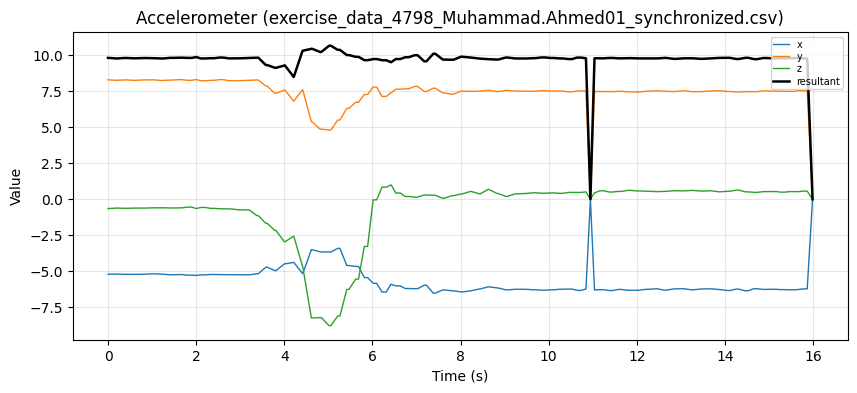

In [13]:
SHOW_ACCEL_X = True
SHOW_ACCEL_Y = True
SHOW_ACCEL_Z = True
SHOW_ACCEL_RESULTANT = True
plot_loaded_sensor(STAND_TO_SIT_DF, "Accelerometer", "accel_x", "accel_y", "accel_z", SHOW_ACCEL_X, SHOW_ACCEL_Y, SHOW_ACCEL_Z, SHOW_ACCEL_RESULTANT, source_label=STAND_TO_SIT_PATH.name if STAND_TO_SIT_PATH else None)


## Stand To Sit Gyroscope

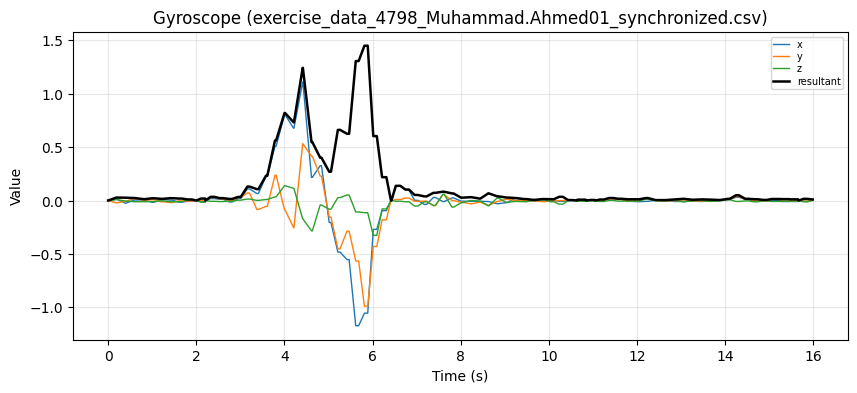

In [14]:
SHOW_GYRO_X = True
SHOW_GYRO_Y = True
SHOW_GYRO_Z = True
SHOW_GYRO_RESULTANT = True
plot_loaded_sensor(STAND_TO_SIT_DF, "Gyroscope", "gyro_x", "gyro_y", "gyro_z", SHOW_GYRO_X, SHOW_GYRO_Y, SHOW_GYRO_Z, SHOW_GYRO_RESULTANT, source_label=STAND_TO_SIT_PATH.name if STAND_TO_SIT_PATH else None)


## Stand To Sit User Accelerometer

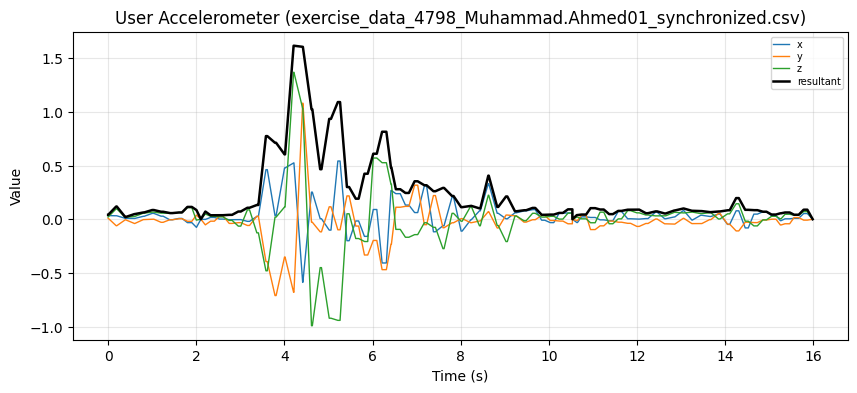

In [15]:
SHOW_USERACC_X = True
SHOW_USERACC_Y = True
SHOW_USERACC_Z = True
SHOW_USERACC_RESULTANT = True
plot_loaded_sensor(STAND_TO_SIT_DF, "User Accelerometer", "useracc_x", "useracc_y", "useracc_z", SHOW_USERACC_X, SHOW_USERACC_Y, SHOW_USERACC_Z, SHOW_USERACC_RESULTANT, source_label=STAND_TO_SIT_PATH.name if STAND_TO_SIT_PATH else None)


## Stand To Sit Feature Plots

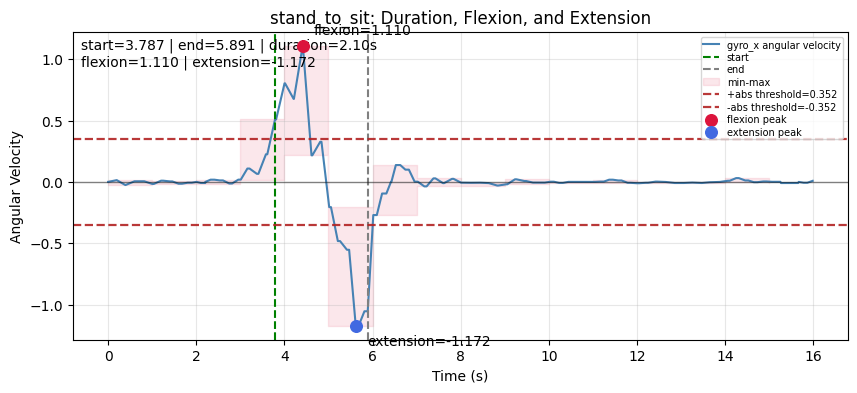

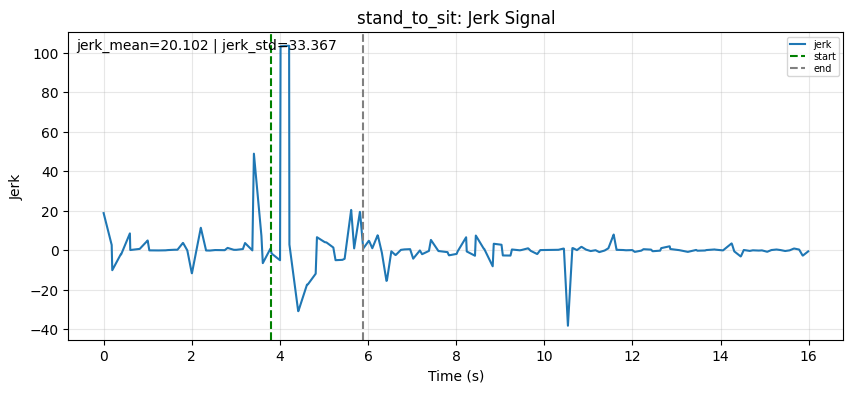

{'activity': 'stand_to_sit', 'start_time_s': 3.7870001792907715, 'end_time_s': 5.891000032424927, 'duration_s': 2.1039998531341553, 'flexion_peak': 1.1096556186676023, 'extension_peak': -1.171925067901611}


,activity,start_time_s,end_time_s,duration_s,flexion_peak,extension_peak
0,stand_to_sit,3.787,5.891,2.104,1.11,-1.172


In [16]:
if STAND_TO_SIT_DF is not None and STAND_TO_SIT_META is not None:
    STAND_TO_SIT_SUMMARY, STAND_TO_SIT_CACHE = plot_transition_validation("stand_to_sit", STAND_TO_SIT_DF, STAND_TO_SIT_META)
    print(STAND_TO_SIT_SUMMARY)
    display(pd.DataFrame([STAND_TO_SIT_SUMMARY]).round(3))
else:
    print("[SKIP] stand_to_sit feature plots: stand_to_sit file not loaded")


## Transition Comparison

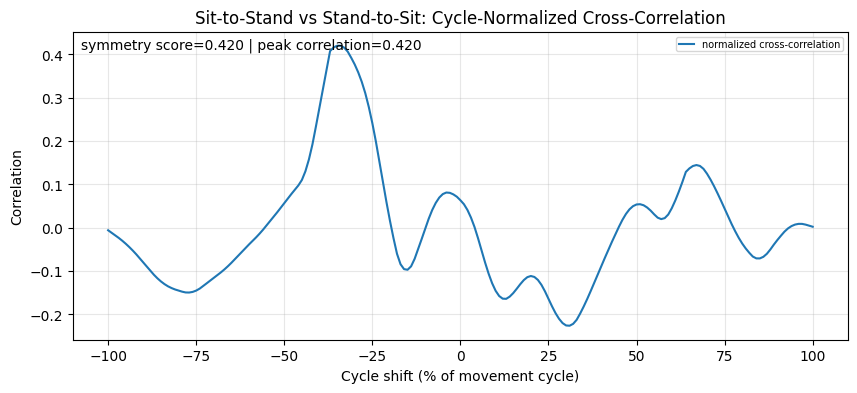

{'activity': 'sitstand_standsit_xcorr', 'xcorr_symmetry_score': 0.41999797038419784, 'xcorr_peak_correlation': 0.41999797038419784}
=== Validation Summary ===


,activity,start_time_s,end_time_s,duration_s,flexion_peak,extension_peak,xcorr_symmetry_score,xcorr_peak_correlation
0,sit_to_stand,3.002,5.218,2.216,1.843,-1.944,NaN,NaN
1,stand_to_sit,3.787,5.891,2.104,1.110,-1.172,NaN,NaN
2,sitstand_standsit_xcorr,NaN,NaN,NaN,NaN,NaN,0.42,0.42


In [17]:
transition_comparisons = []
if SIT_TO_STAND_CACHE is not None and STAND_TO_SIT_CACHE is not None:
    trans_corr = plot_transition_pair_xcorr(SIT_TO_STAND_CACHE, STAND_TO_SIT_CACHE)
    transition_comparisons.append(trans_corr)
    print(trans_corr)
else:
    print("[SKIP] transition comparison: need both sit_to_stand and stand_to_sit")
print("=== Validation Summary ===")
display(pd.DataFrame(([s for s in [SIT_TO_STAND_SUMMARY, STAND_TO_SIT_SUMMARY] if s is not None] + transition_comparisons)).round(3))


In [18]:
# Calculated linear and nonlinear transition features from the loaded synchronized sit/stand files
from imu_features.transition_features import extract_transition_features


sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
sv._apply_notebook_window_gate_settings()

transition_feature_specs = [
    ("duration", "Linear"),
    ("time_to_peak_acc", "Linear"),
    ("peak_acc", "Linear"),
    ("flexion_peak", "Linear"),
    ("extension_peak", "Linear"),
    ("peak_gyro", "Linear"),
    ("acc_rms", "Linear"),
    ("jerk_mean", "Linear"),
    ("jerk_std", "Linear"),
    ("peak_count", "Linear"),
    ("entropy", "Nonlinear"),
]

transition_rows = []

if SIT_TO_STAND_DF is not None and SIT_TO_STAND_META is not None:
    sit_to_stand_features = extract_transition_features(
        SIT_TO_STAND_DF, SIT_TO_STAND_META, PIPELINE_CONFIG, prefix="sit_to_stand"
    )
    if SIT_TO_STAND_SUMMARY is not None:
        sit_to_stand_features["sit_to_stand_duration"] = SIT_TO_STAND_SUMMARY.get("duration_s", np.nan)
        sit_to_stand_features["sit_to_stand_flexion_peak"] = SIT_TO_STAND_SUMMARY.get("flexion_peak", np.nan)
        sit_to_stand_features["sit_to_stand_extension_peak"] = SIT_TO_STAND_SUMMARY.get("extension_peak", np.nan)
    for suffix, feature_type in transition_feature_specs:
        feature = f"sit_to_stand_{suffix}"
        transition_rows.append({
            "Activity": "sit_to_stand",
            "Feature": feature,
            "Type": feature_type,
            "Value": sit_to_stand_features.get(feature, np.nan),
        })
else:
    print("[SKIP] sit_to_stand values: sit_to_stand file not loaded")

if STAND_TO_SIT_DF is not None and STAND_TO_SIT_META is not None:
    stand_to_sit_features = extract_transition_features(
        STAND_TO_SIT_DF, STAND_TO_SIT_META, PIPELINE_CONFIG, prefix="stand_to_sit"
    )
    if STAND_TO_SIT_SUMMARY is not None:
        stand_to_sit_features["stand_to_sit_duration"] = STAND_TO_SIT_SUMMARY.get("duration_s", np.nan)
        stand_to_sit_features["stand_to_sit_flexion_peak"] = STAND_TO_SIT_SUMMARY.get("flexion_peak", np.nan)
        stand_to_sit_features["stand_to_sit_extension_peak"] = STAND_TO_SIT_SUMMARY.get("extension_peak", np.nan)
    for suffix, feature_type in transition_feature_specs:
        feature = f"stand_to_sit_{suffix}"
        transition_rows.append({
            "Activity": "stand_to_sit",
            "Feature": feature,
            "Type": feature_type,
            "Value": stand_to_sit_features.get(feature, np.nan),
        })
else:
    print("[SKIP] stand_to_sit values: stand_to_sit file not loaded")


if SIT_TO_STAND_CACHE is not None and STAND_TO_SIT_CACHE is not None:
    _, _, xcorr_peak, xcorr_symmetry_score, _ = sv._best_xcorr_summary(SIT_TO_STAND_CACHE, STAND_TO_SIT_CACHE, n_points=101)
    for feature, value in {
        "sitstand_standsit_xcorr_symmetry_score": xcorr_symmetry_score,
        "sitstand_standsit_xcorr_peak_correlation": xcorr_peak,
    }.items():
        transition_rows.append({
            "Activity": "sit_to_stand_vs_stand_to_sit",
            "Feature": feature,
            "Type": "Nonlinear",
            "Value": value,
        })

if transition_rows:
    transition_feature_table = pd.DataFrame(transition_rows)
    transition_feature_table["Value"] = pd.to_numeric(transition_feature_table["Value"], errors="coerce")
    transition_display_table = transition_feature_table.copy()
    transition_display_table["Value"] = transition_display_table["Value"].map(lambda value: f"{value:.3f}" if pd.notna(value) else np.nan)
    display(transition_display_table)
else:
    print("[SKIP] transition feature table: no transition files loaded")


,Activity,Feature,Type,Value
0,sit_to_stand,sit_to_stand_duration,Linear,2.216
1,sit_to_stand,sit_to_stand_time_to_peak_acc,Linear,1.202
2,sit_to_stand,sit_to_stand_peak_acc,Linear,3.030
3,sit_to_stand,sit_to_stand_flexion_peak,Linear,1.843
4,sit_to_stand,sit_to_stand_extension_peak,Linear,-1.944
5,sit_to_stand,sit_to_stand_peak_gyro,Linear,2.004
6,sit_to_stand,sit_to_stand_acc_rms,Linear,1.295
7,sit_to_stand,sit_to_stand_jerk_mean,Linear,38.208
8,sit_to_stand,sit_to_stand_jerk_std,Linear,99.913
9,sit_to_stand,sit_to_stand_peak_count,Linear,3.000
